# Notebook 02 - Veri Görselleştirme

## Enerji Perakende Veri Analizi Case Study

### Amaç

Bu notebook, enerji tüketimi ve tahsilat verilerinin görselleştirilmesini kapsamaktadır.

Bu çalışma kapsamında;

- İlçelere göre hesap sınıfı dağılımları karşılaştırılacaktır.
- Aylık ortalama elektrik tüketimi incelenecektir.
- Tahsilat verilerindeki ilçe ve şube dağılımları görselleştirilecektir.
- Zamanında ve geç ödeme oranları analiz edilecektir.
- kWh tüketim dağılımı histogram ve kutu grafiği ile incelenecektir.

Bu notebook yalnızca veri görselleştirme ve karşılaştırmalı analiz çalışmalarını kapsamaktadır.

## 1. Kütüphanelerin Yüklenmesi

Bu bölümde veri analizi ve görselleştirme için kullanılacak Python kütüphaneleri projeye dahil edilmektedir.

In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

plt.style.use("ggplot")

%matplotlib inline

## 2. Veri Setlerinin Yüklenmesi

Bu bölümde analizde kullanılacak Excel dosyası okunmakta ve tüm çalışma sayfaları ayrı DataFrame'ler olarak yüklenmektedir.

In [ ]:
# Excel dosyasının yolu
file_path = "../data/elektrik_veri.xlsx"

# Excel dosyasını açma
xls = pd.ExcelFile(file_path)

# Veri setlerini yükleme
df_tahsilat = pd.read_excel(xls, sheet_name="Tahsilat")
df_tahsilat_1 = pd.read_excel(xls, sheet_name="Tahsilat 1")

df_tahakkuk = pd.read_excel(xls, sheet_name="Tahakkuk")
df_tahakkuk_1 = pd.read_excel(xls, sheet_name="Tahakkuk 1")
df_tahakkuk_2 = pd.read_excel(xls, sheet_name="Tahakkuk 2")

print("Veri setleri başarıyla yüklendi.")

Veri setleri başarıyla yüklendi.


## 3. Görselleştirme İçin Veri Hazırlığı

Bu bölümde üç ilçeye ait tahakkuk verileri tek bir veri setinde birleştirilmektedir.

Grafikler ve karşılaştırmalı analizler bu veri seti üzerinden gerçekleştirilecektir.

In [ ]:
# Tahakkuk verilerini birleştirme

df_tahakkuk_tum = pd.concat(
    [df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2],
    ignore_index=True
)

print("Toplam kayıt sayısı:", len(df_tahakkuk_tum))

Toplam kayıt sayısı: 1185698



## 4. İlçelere Göre Hesap Sınıfı Dağılımı

Bu bölümde Hamamözü, Gümüşhacıköy ve Göynücek ilçelerindeki hesap sınıfı dağılımları yan yana sütun grafiklerle karşılaştırılmaktadır.

Grafiklerin okunabilir olması için her ilçede en fazla kayda sahip ilk 10 hesap sınıfı gösterilmektedir.

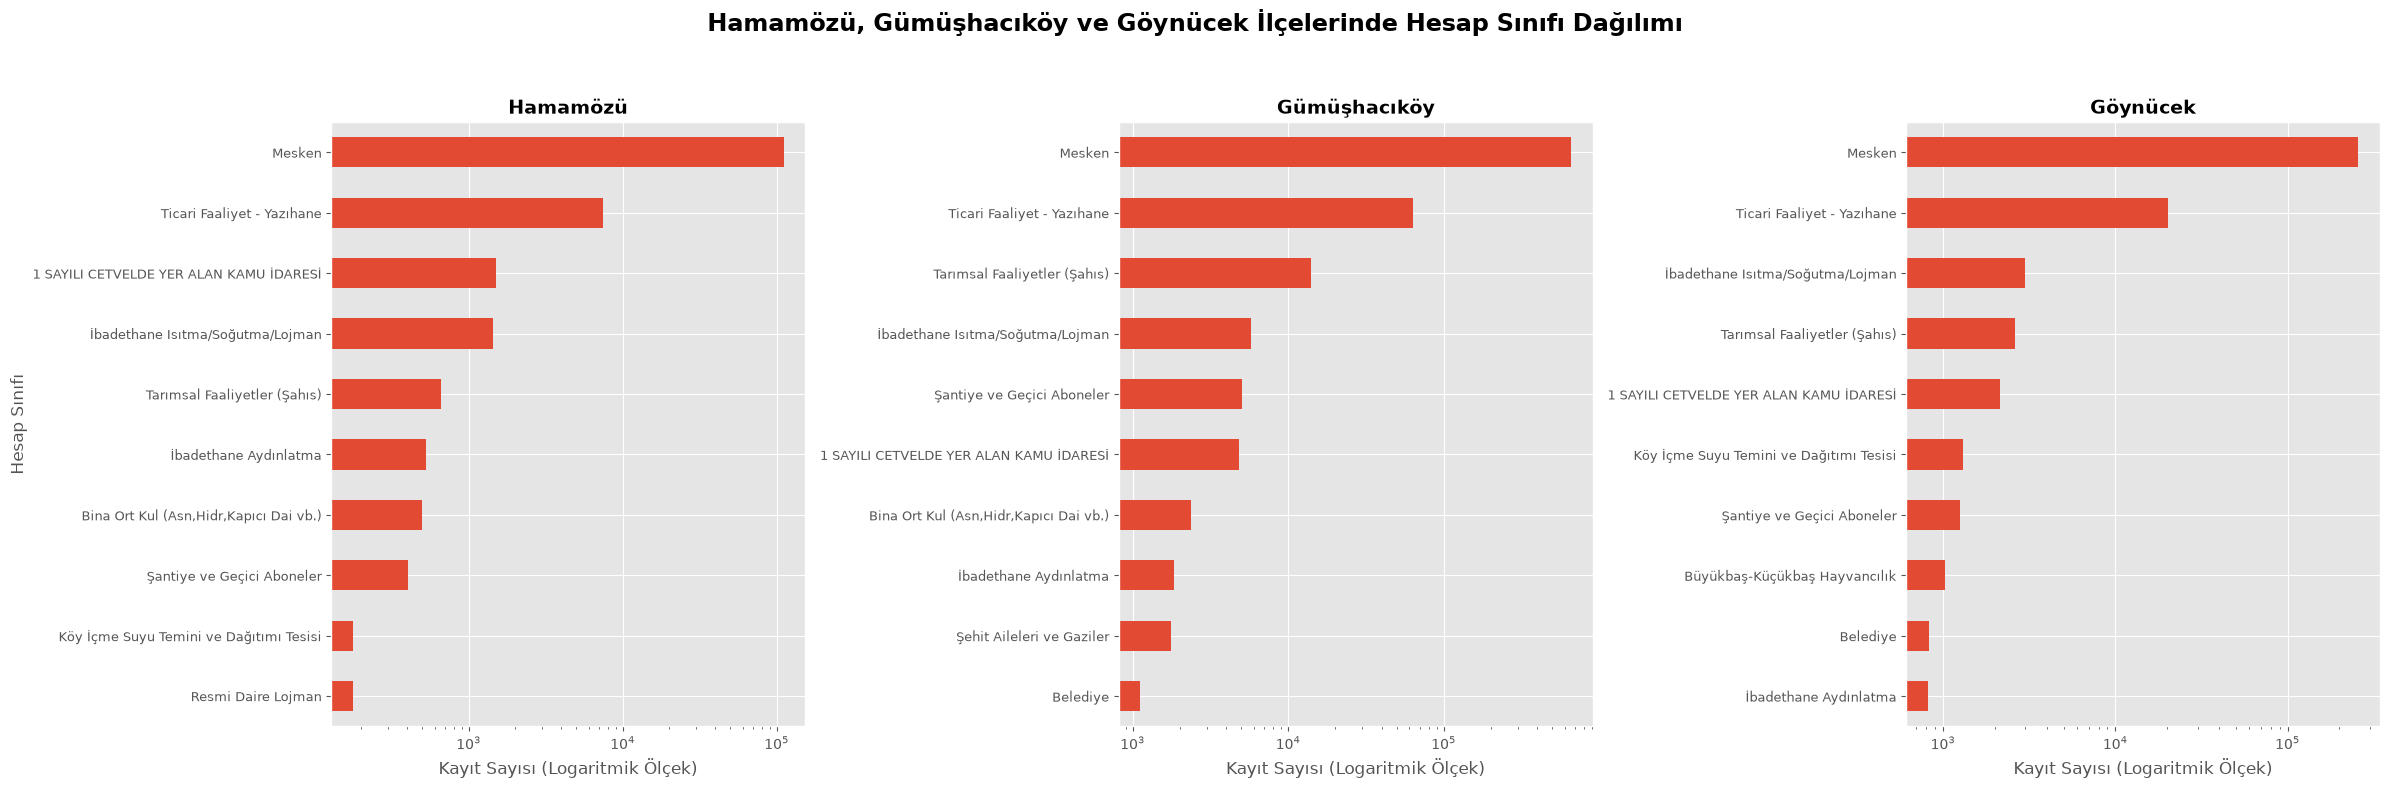

In [ ]:
# İlçelere ait tahakkuk veri setleri

ilce_verileri = {
    "Hamamözü": df_tahakkuk,
    "Gümüşhacıköy": df_tahakkuk_1,
    "Göynücek": df_tahakkuk_2
}

# Üç ilçeyi yan yana gösteren subplot oluşturma

fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 8)
)

for i, (ax, (ilce_adi, veri)) in enumerate(
    zip(axes, ilce_verileri.items())
):

    hesap_sinifi_dagilimi = (
        veri["Hesap Sınıfı"]
        .value_counts()
        .head(10)
        .sort_values(ascending=True)
    )

    hesap_sinifi_dagilimi.plot(
        kind="barh",
        ax=ax
    )

    # Mesken dışındaki düşük frekanslı sınıfları daha görünür hale getirme
    ax.set_xscale("log")

    ax.set_title(
        ilce_adi,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Kayıt Sayısı (Logaritmik Ölçek)")

    # Y ekseni başlığı yalnızca ilk grafikte gösterilir
    if i == 0:
        ax.set_ylabel("Hesap Sınıfı")
    else:
        ax.set_ylabel("")

    ax.tick_params(axis="y", labelsize=9)

fig.suptitle(
    "Hamamözü, Gümüşhacıköy ve Göynücek İlçelerinde Hesap Sınıfı Dağılımı",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig(
    "../outputs/figures/ilce_hesap_sinifi_dagilimi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Değerlendirme

Üç ilçede de en yaygın hesap sınıfının **Mesken** olduğu görülmektedir.

Mesken kayıtları diğer hesap sınıflarına göre çok daha yüksek olduğu için yatay eksende logaritmik ölçek kullanılmıştır. Böylece daha düşük frekansa sahip hesap sınıfları da okunabilir hale getirilmiştir.

İlçeler genel olarak benzer bir müşteri profiline sahip olmakla birlikte, bazı özel abonelik türlerinin ilçelere göre farklılaştığı görülmektedir.

---
## 5. İlçelerin Aylık Ortalama Elektrik Tüketimi

Bu bölümde Hamamözü, Gümüşhacıköy ve Göynücek ilçelerindeki aylık ortalama elektrik tüketimleri karşılaştırılmaktadır.

Fatura dönemlerine göre hesaplanan ortalama kWh değerleri tek bir çizgi grafikte gösterilerek ilçelerin tüketim eğilimleri analiz edilmektedir.

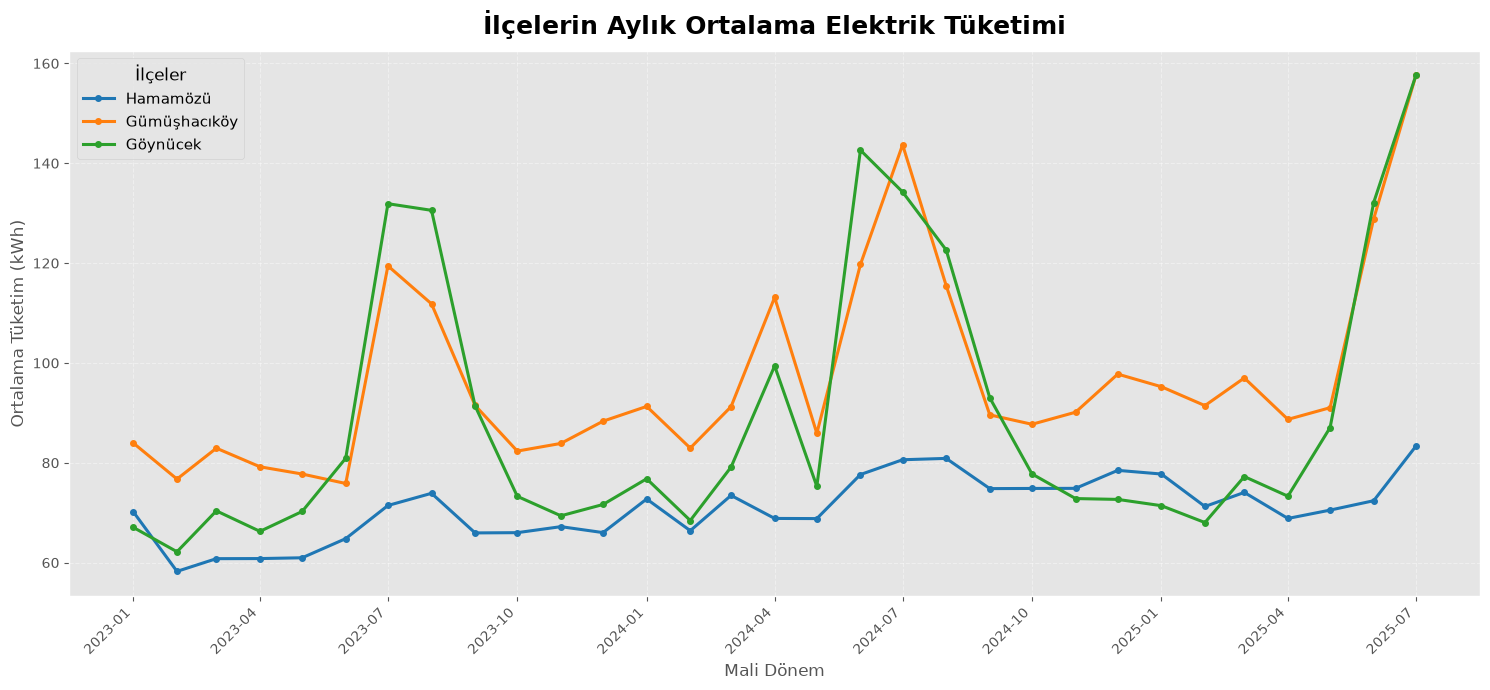

In [ ]:
# İlçelere ait tahakkuk veri setleri

ilce_verileri = {
    "Hamamözü": df_tahakkuk,
    "Gümüşhacıköy": df_tahakkuk_1,
    "Göynücek": df_tahakkuk_2
}

# İlçeler için sabit renkler

renkler = {
    "Hamamözü": "#1f77b4",
    "Gümüşhacıköy": "#ff7f0e",
    "Göynücek": "#2ca02c"
}

# Grafik alanını oluşturma

plt.figure(figsize=(15, 7))

for ilce_adi, veri in ilce_verileri.items():

    # Orijinal DataFrame'i değiştirmemek için kopya oluşturma
    veri = veri.copy()

    # Mali dönem sütununu tarih formatına dönüştürme
    veri["mali_yil_donem"] = pd.to_datetime(
        veri["mali_yil_donem"],
        errors="coerce"
    )

    # Geçersiz tarih kayıtlarını analiz dışında bırakma
    veri = veri.dropna(subset=["mali_yil_donem"])

    # Her mali dönem için ortalama kWh tüketimini hesaplama
    aylik_ortalama = (
        veri
        .groupby("mali_yil_donem", as_index=True)["kwh"]
        .mean()
        .sort_index()
    )

    # İlçenin tüketim eğrisini çizme
    plt.plot(
        aylik_ortalama.index,
        aylik_ortalama.values,
        marker="o",
        markersize=4,
        linewidth=2.2,
        color=renkler[ilce_adi],
        label=ilce_adi
    )

# Grafik başlığı ve eksen isimleri

plt.title(
    "İlçelerin Aylık Ortalama Elektrik Tüketimi",
    fontsize=18,
    fontweight="bold",
    pad=12
)

plt.xlabel(
    "Mali Dönem",
    fontsize=12
)

plt.ylabel(
    "Ortalama Tüketim (kWh)",
    fontsize=12
)

# Açıklama kutusu

plt.legend(
    title="İlçeler",
    fontsize=11,
    title_fontsize=12,
    loc="upper left"
)

# Izgara ve tarih etiketleri

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.xticks(
    rotation=45,
    ha="right"
)

# Kenar boşluklarını düzenleme

plt.tight_layout()

# Grafiği kaydetme

plt.savefig(
    "../outputs/figures/aylik_ortalama_tuketim.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Değerlendirme

Üç ilçenin aylık ortalama elektrik tüketimleri karşılaştırıldığında belirli dönemlerde benzer tüketim hareketleri gösterdikleri görülmektedir.

**Hamamözü**, genel olarak diğer iki ilçeye göre daha düşük ve daha dengeli bir tüketim profiline sahiptir.

**Gümüşhacıköy** ve **Göynücek** ilçelerinde özellikle yaz dönemlerinde ortalama tüketim değerlerinin belirgin şekilde arttığı görülmektedir. Bu artışlar mevsimsel tüketim davranışları, tarımsal faaliyetler veya hesap sınıfı dağılımlarıyla ilişkili olabilir.

2025 yılının ortasında üç ilçede de ortalama tüketimde yükseliş görülmektedir. Ancak bu yükselişin kesin nedeni mevcut grafik üzerinden belirlenemeyeceği için sonraki analizlerde müşteri ve hesap sınıfı yapısıyla birlikte değerlendirilmesi gerekmektedir.

---
## 6. Tahsilat Kayıtlarının İlçe ve Şube Dağılımı

Bu bölümde tahsilat kayıtlarının ilçelere ve ödeme yapılan şubelere göre dağılımı incelenmektedir.

İlçe dağılımı tüm kategoriler üzerinden, şube dağılımı ise grafiğin okunabilir olması için en fazla kayda sahip ilk 10 şube üzerinden gösterilmektedir.

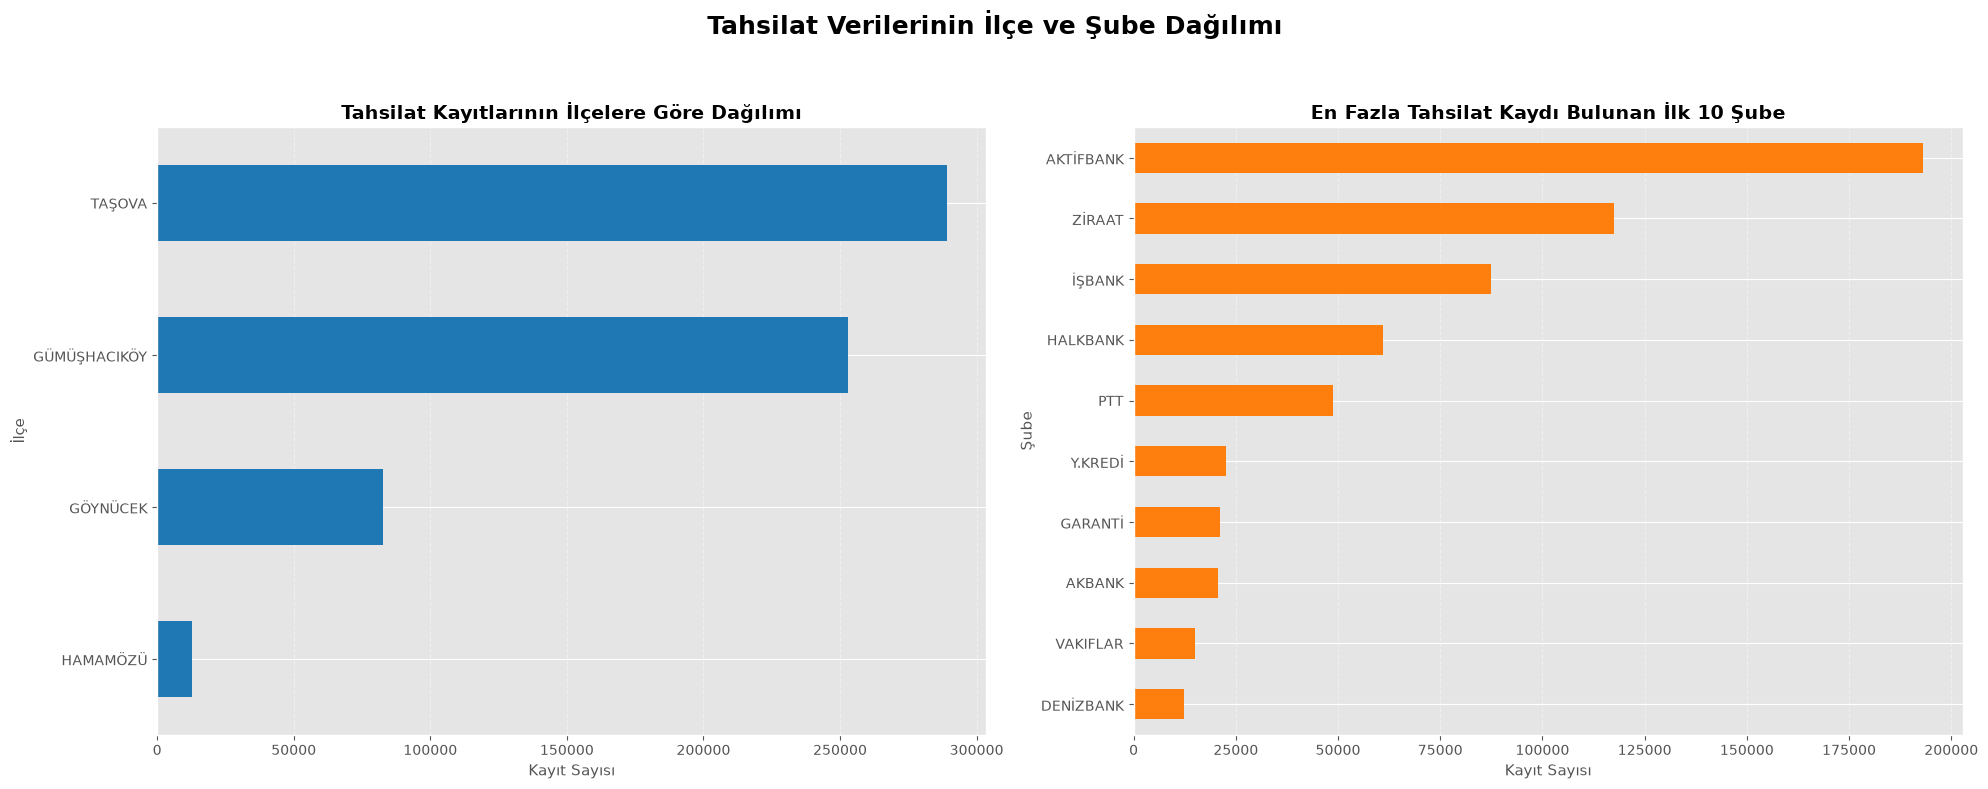

In [ ]:
# İlçe ve şube dağılımlarını hesaplama

ilce_dagilimi = (
    df_tahsilat["İlçe"]
    .value_counts()
    .sort_values(ascending=True)
)

sube_dagilimi = (
    df_tahsilat["Şube"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

# Yan yana iki yatay bar chart oluşturma

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 8)
)

# İlçe dağılımı

ilce_dagilimi.plot(
    kind="barh",
    ax=axes[0],
    color="#1f77b4"
)

axes[0].set_title(
    "Tahsilat Kayıtlarının İlçelere Göre Dağılımı",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Kayıt Sayısı", fontsize=11)
axes[0].set_ylabel("İlçe", fontsize=11)

axes[0].grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

# Şube dağılımı

sube_dagilimi.plot(
    kind="barh",
    ax=axes[1],
    color="#ff7f0e"
)

axes[1].set_title(
    "En Fazla Tahsilat Kaydı Bulunan İlk 10 Şube",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Kayıt Sayısı", fontsize=11)
axes[1].set_ylabel("Şube", fontsize=11)

axes[1].grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

# Ana başlık

fig.suptitle(
    "Tahsilat Verilerinin İlçe ve Şube Dağılımı",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

# Grafiği kaydetme

plt.savefig(
    "../outputs/figures/tahsilat_ilce_sube_dagilimi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Değerlendirme

Tahsilat kayıtlarının büyük bölümü **Taşova** ve **Gümüşhacıköy** ilçelerinde yoğunlaşmaktadır. **Hamamözü** ilçesinin toplam tahsilat kayıt sayısı diğer ilçelere göre belirgin şekilde daha düşüktür.

Şube bazında incelendiğinde en fazla tahsilat kaydının **Aktifbank**, **Ziraat Bankası** ve **İş Bankası** üzerinden gerçekleştirildiği görülmektedir.

Tahsilat işlemlerinin belirli banka ve şubelerde yoğunlaşması, müşterilerin ödeme kanalı tercihleri hakkında önemli bir gösterge sunmaktadır.

---
## 7. Tahsilat Türlerinin Dağılımı

Bu bölümde tahsilat işlemlerinin ödeme yöntemlerine göre dağılımı incelenmektedir.

Nakit, Banka, Mahsuben ve Kredi Kartı tahsilatlarının toplam tahsilat içerisindeki payları karşılaştırılarak müşterilerin ödeme kanalı tercihleri değerlendirilmektedir.

In [ ]:
# Tahsilat türlerinin toplam tutarlarını hesaplama

tahsilat_toplamlari = {
    "Nakit": df_tahsilat["Nakit Tahsilat"].fillna(0).sum(),
    "Banka": df_tahsilat["Banka Tahsilatı"].fillna(0).sum(),
    "Mahsuben": df_tahsilat["Mahsuben Tahsilat"].fillna(0).sum(),
    "Kredi Kartı": df_tahsilat["Kredi Kartı Tahsilatı"].fillna(0).sum()
}

tahsilat_df = pd.DataFrame(
    list(tahsilat_toplamlari.items()),
    columns=["Tahsilat Türü", "Toplam Tutar"]
)

tahsilat_df

,Tahsilat Türü,Toplam Tutar
0,Nakit,3.634675e+05
1,Banka,2.343587e+08
2,Mahsuben,4.661093e+07
3,Kredi Kartı,0.000000e+00


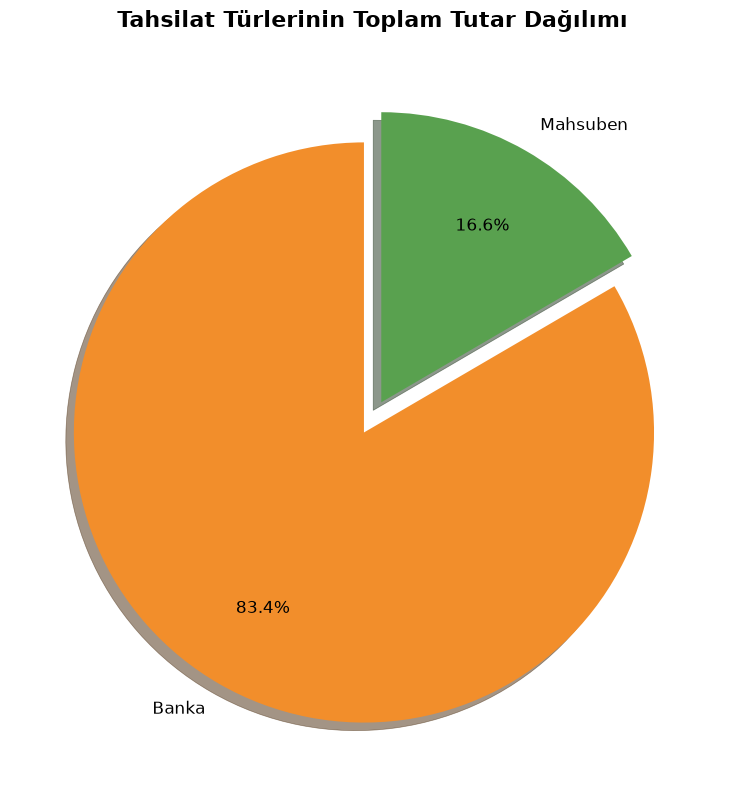

In [ ]:
# Çok küçük paya sahip tahsilat türlerini çıkarma
tahsilat_grafik = tahsilat_df[
    tahsilat_df["Toplam Tutar"] > 500000
].copy()

# Renkler
renkler = ["#F28E2B", "#59A14F"]

plt.figure(figsize=(8, 8))

plt.pie(
    tahsilat_grafik["Toplam Tutar"],
    labels=tahsilat_grafik["Tahsilat Türü"],
    autopct="%1.1f%%",
    startangle=90,
    colors=renkler,
    explode=[0.06, 0.06],
    shadow=True,
    textprops={"fontsize":12},
    pctdistance=0.70,
    labeldistance=1.10
)

plt.title(
    "Tahsilat Türlerinin Toplam Tutar Dağılımı",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/tahsilat_turleri_dagilimi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Değerlendirme

Tahsilat tutarlarının büyük bölümü banka kanalı üzerinden gerçekleştirilmektedir.

Mahsuben tahsilatlar toplam tahsilatın yaklaşık %17'sini oluşturmaktadır.

Nakit tahsilatlar toplam tahsilat tutarı içerisinde oldukça düşük bir paya sahip olduğundan grafik üzerinde gösterilmemiştir.

Veri setinde kredi kartı tahsilatına ait kayıt bulunmadığından bu ödeme yöntemi analiz kapsamına alınmamıştır.

## 8. Zamanında ve Geç Ödeme Analizi

Bu bölümde tahakkukların son ödeme tarihine göre hangi dönemde tahsil edildiği incelenmektedir.

Tahsilatların zamanında mı yoksa gecikmeli mi gerçekleştiği analiz edilerek ödeme davranışları değerlendirilmektedir.

In [64]:
# Geç ödeme analizinde kullanılacak sütunlar

odeme_sutunlari = [
    "Son Ödeme Tarihinden Önceki Tahsilat",
    "Son Ödeme Tarihindeki Tahsilat",
    "Son Ödeme (1)",
    "Son Ödeme (2)",
    "Son Ödeme (3)",
    "Son Ödeme (4)",
    "Son Ödeme (5)",
    "Son Ödeme (6-10)",
    "Son Ödeme (10-20)",
    "Son Ödeme (20-30)",
    "Son Ödeme (30-60)",
    "Son Ödeme (60-90)",
    "Son Ödeme (90-120)",
    "Son Ödeme (120-150)",
    "Son Ödeme (150-180)",
    "Son Ödeme (180+)"
]

print("Toplam ödeme sütunu:", len(odeme_sutunlari))
print(odeme_sutunlari)

Toplam ödeme sütunu: 16
['Son Ödeme Tarihinden Önceki Tahsilat', 'Son Ödeme Tarihindeki Tahsilat', 'Son Ödeme (1)', 'Son Ödeme (2)', 'Son Ödeme (3)', 'Son Ödeme (4)', 'Son Ödeme (5)', 'Son Ödeme (6-10)', 'Son Ödeme (10-20)', 'Son Ödeme (20-30)', 'Son Ödeme (30-60)', 'Son Ödeme (60-90)', 'Son Ödeme (90-120)', 'Son Ödeme (120-150)', 'Son Ödeme (150-180)', 'Son Ödeme (180+)']


In [ ]:
# Her ödeme dönemindeki toplam tahsilat tutarını hesaplama

odeme_toplamlari = (
    df_tahsilat_1[odeme_sutunlari]
    .fillna(0)
    .sum()
    .sort_values(ascending=False)
)

odeme_toplamlari

Son Ödeme Tarihindeki Tahsilat          1.796084e+08
Son Ödeme Tarihinden Önceki Tahsilat    1.287200e+08
Son Ödeme (10-20)                       2.817479e+07
Son Ödeme (6-10)                        2.553449e+07
Son Ödeme (20-30)                       2.323351e+07
Son Ödeme (30-60)                       2.115577e+07
Son Ödeme (1)                           1.344127e+07
Son Ödeme (2)                           1.199557e+07
Son Ödeme (4)                           9.115503e+06
Son Ödeme (60-90)                       9.035385e+06
Son Ödeme (3)                           7.829993e+06
Son Ödeme (5)                           3.779220e+06
Son Ödeme (90-120)                      2.565664e+06
Son Ödeme (180+)                        7.712417e+05
Son Ödeme (120-150)                     7.416220e+05
Son Ödeme (150-180)                     6.101012e+05
dtype: float64

In [ ]:
# Grafik için DataFrame oluşturma

odeme_df = odeme_toplamlari.reset_index()

odeme_df.columns = [
    "Ödeme Dönemi",
    "Toplam Tahsilat"
]

odeme_df

,Ödeme Dönemi,Toplam Tahsilat
0,Son Ödeme Tarihindeki Tahsilat,1.796084e+08
1,Son Ödeme Tarihinden Önceki Tahsilat,1.287200e+08
2,Son Ödeme (10-20),2.817479e+07
3,Son Ödeme (6-10),2.553449e+07
4,Son Ödeme (20-30),2.323351e+07
5,Son Ödeme (30-60),2.115577e+07
6,Son Ödeme (1),1.344127e+07
7,Son Ödeme (2),1.199557e+07
8,Son Ödeme (4),9.115503e+06
9,Son Ödeme (60-90),9.035385e+06


### Zamanında ve Geç Ödeme Dağılımı

Aşağıdaki grafik tahsilatların hangi ödeme döneminde gerçekleştiğini göstermektedir.

Grafik sayesinde tahsilatların zamanında mı yoksa gecikmeli mi yapıldığı kolayca analiz edilebilmektedir.

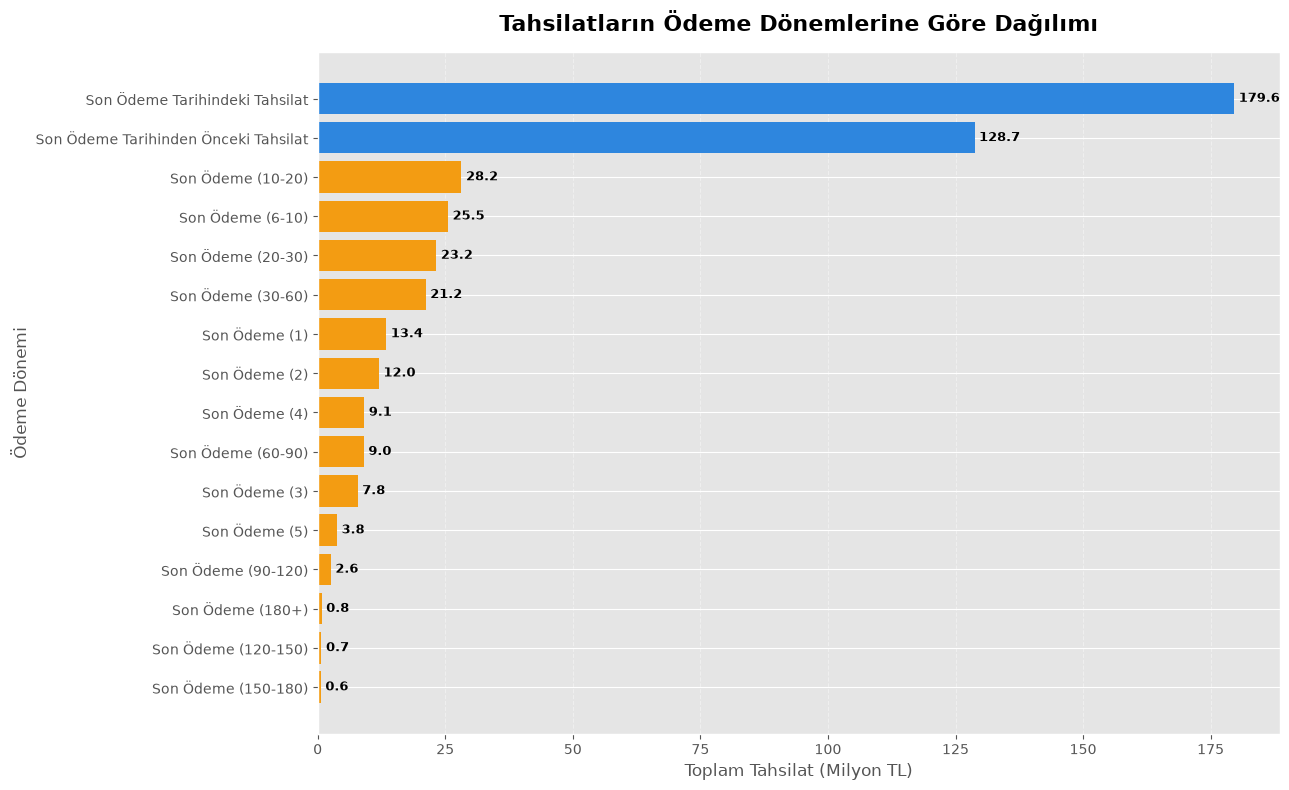

In [ ]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(13,8))

renkler = [
    "#2E86DE" if "Tarih" in x else "#F39C12"
    for x in odeme_df["Ödeme Dönemi"]
]

bars = plt.barh(
    odeme_df["Ödeme Dönemi"],
    odeme_df["Toplam Tahsilat"],
    color=renkler
)

plt.title(
    "Tahsilatların Ödeme Dönemlerine Göre Dağılımı",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Toplam Tahsilat (Milyon TL)", fontsize=12)
plt.ylabel("Ödeme Dönemi", fontsize=12)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f}")
)

# Değerleri çubukların üzerine yazma
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 900_000,
        bar.get_y() + bar.get_height()/2,
        f"{width/1_000_000:.1f}",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="black"
    )

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/odeme_donemi_dagilimi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Değerlendirme

Tahsilatların önemli bir bölümü son ödeme tarihinde veya son ödeme tarihinden önce gerçekleştirilmektedir.

Gecikmeli tahsilatlar içerisinde en yüksek pay 6-30 gün arası gecikmelerde görülmektedir.

90 gün ve üzeri gecikmeli tahsilatlar toplam tahsilat tutarı içerisinde oldukça düşük bir paya sahiptir. Bu durum uzun süreli gecikmelerin sınırlı düzeyde olduğunu göstermektedir.

## 9. kWh Tüketim Dağılımı ve Aykırı Değerler

Bu bölümde elektrik tüketim değerlerinin dağılımı histogram ve kutu grafiği ile incelenmektedir.

Negatif tüketim kayıtları ve aşırı uç değerler daha önce veri kalitesi kapsamında analiz edilmiştir. Görselleştirmede dağılımın daha okunabilir olması amacıyla yalnızca negatif olmayan tüketim değerleri kullanılmaktadır.

In [ ]:
# Negatif olmayan kWh değerlerini seçme
kwh_pozitif = df_tahakkuk_tum.loc[
    df_tahakkuk_tum["kwh"] >= 0,
    "kwh"
].copy()

# Dağılımın okunabilir olması için %99'luk üst sınırı hesaplama
ust_sinir = kwh_pozitif.quantile(0.99)

# Histogramda kullanılacak veri
kwh_gorsel = kwh_pozitif[
    kwh_pozitif <= ust_sinir
]

print("Pozitif kayıt sayısı :", len(kwh_pozitif))
print("%99 üst sınırı      :", round(ust_sinir, 2))
print("Grafikte kullanılan kayıt sayısı :", len(kwh_gorsel))

Pozitif kayıt sayısı : 1185547
%99 üst sınırı      : 509.16
Grafikte kullanılan kayıt sayısı : 1173691


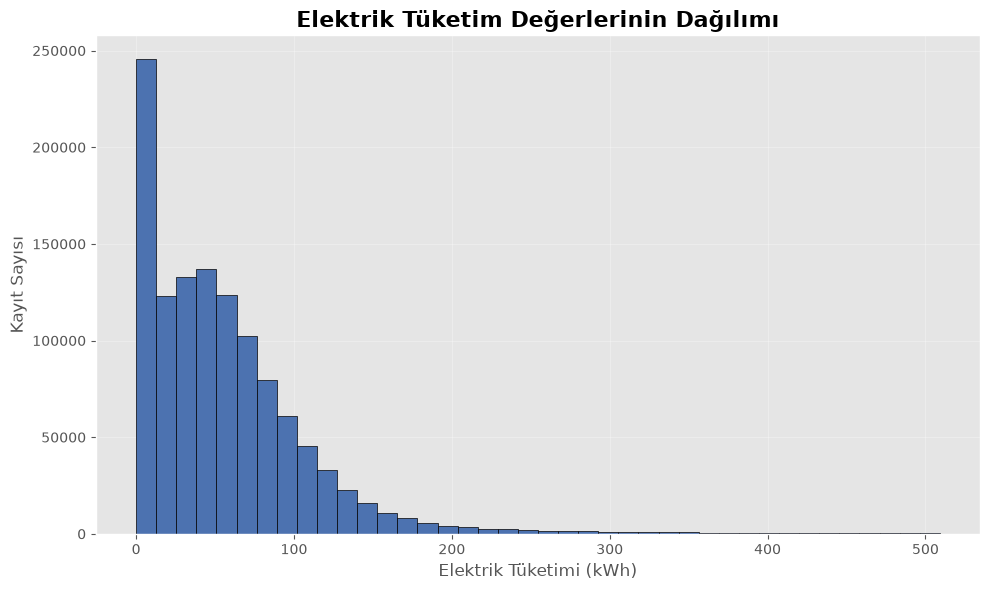

In [69]:
plt.figure(figsize=(10, 6))

plt.hist(
    kwh_gorsel,
    bins=40,
    color="#4C72B0",
    edgecolor="black"
)

plt.title(
    "Elektrik Tüketim Değerlerinin Dağılımı",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Elektrik Tüketimi (kWh)")
plt.ylabel("Kayıt Sayısı")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/kwh_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

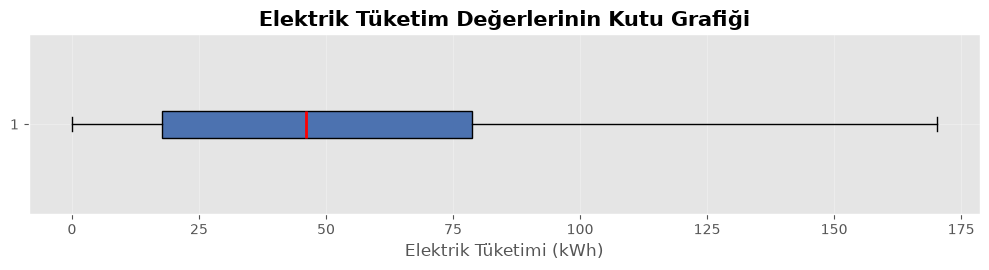

In [71]:
plt.figure(figsize=(10, 2.8))

plt.boxplot(
    kwh_gorsel,
    orientation="horizontal",
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="#4C72B0"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black")
)

plt.title(
    "Elektrik Tüketim Değerlerinin Kutu Grafiği",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Elektrik Tüketimi (kWh)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/kwh_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Değerlendirme

Histogram incelendiğinde elektrik tüketim değerlerinin sağa çarpık bir dağılım gösterdiği görülmektedir. Kayıtların büyük bölümü düşük tüketim aralığında yoğunlaşırken, az sayıdaki yüksek tüketim değerleri dağılımın sağ kuyruğunu oluşturmaktadır.

Kutu grafiği, veri setinde çok sayıda aykırı tüketim değeri bulunduğunu göstermektedir. Bu durum özellikle ticari veya yüksek tüketimli abonelerin varlığından kaynaklanabilir. Analizlerde bu aykırı değerler dikkate alınmalı, ancak veri setinden doğrudan çıkarılmamalıdır.
